# Quick Start Example to Intel RealSense with Python

This experiment is a quick start to to demonstrate intel realsense with python. This is to only visualize the Depth and RGB interface on Intel RealSense with the RealSense Viewer. The demo will query sensors in the connected device, then it will display depth and color frames using Pipeline API.

## Pre Requisite Installations 
- Download Python 3.7 or later
- Install Jupyter Notebook
- Download get-pip.py and run the fllowing commands in Jupyter terminal : <br>
- python get-pip.py - Pip tool to install Pip Python package<br>
pip install pyrealsense2 - Intel RealSense cross-platform open source API<br>
pip install numpy - Fundamental package for scientific computing<br>
pip install matplotlib - 2D plotting library producing publication quality figure<br>
pip install opencv-python - OpenCV packages for Python<br>
<br>
For the one's working with linux install : udev-rulesthon


In [1]:
# Import the requied packages and libraries
import os
import numpy as np                        # Fundamental package for scientific computing
import matplotlib.pyplot as plt           # 2D plotting library producing publication quality figures
from IPython.display import clear_output  # Clear the screen
import pyrealsense2 as rs                 # Intel RealSense cross-platform open-source API

print("Environment is Ready")

Environment is Ready


## Create a Pipeline 
The pipe-line is a high level API for :<br> 
- streaming and processing frames
- Abstracting camera configurations
- Smplifying user interaction with the device and the vision processing module
<br>
<br>
Config is a utility object used by a pipeline

In [2]:
pipe = rs.pipeline()                      # Create a pipeline
cfg = rs.config()                         # Create a default configuration

print("Pipeline is created")

Pipeline is created


## Find RealSense Device 

In [3]:
print("Searching Devices..")
selected_devices = []                     # Store connected device(s)

for d in rs.context().devices:
    selected_devices.append(d)
    print(d.get_info(rs.camera_info.name))
if not selected_devices:
    print("No RealSense device is connected!")

Searching Devices..
Intel RealSense D435


## Find Depth and RGB Sensor

In [4]:
rgb_sensor = depth_sensor = None

for device in selected_devices:                         
    print("Required sensors for device:", device.get_info(rs.camera_info.name))
    for s in device.sensors:                              # Show available sensors in each device
        if s.get_info(rs.camera_info.name) == 'RGB Camera':
            print(" - RGB sensor found")
            rgb_sensor = s                                # Set RGB sensor
        if s.get_info(rs.camera_info.name) == 'Stereo Module':
            depth_sensor = s                              # Set Depth sensor
            print(" - Depth sensor found")

Required sensors for device: Intel RealSense D435
 - Depth sensor found
 - RGB sensor found


## Display Depth and Color Frames 

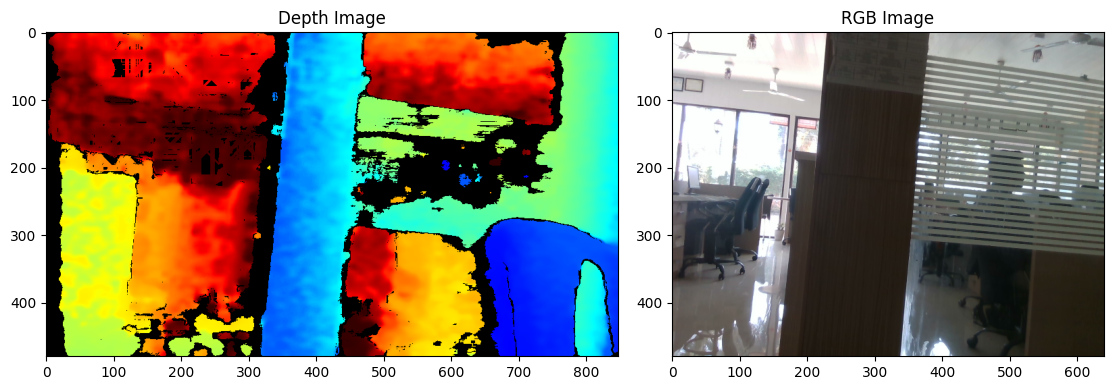

Done!


In [5]:
colorizer = rs.colorizer()                                # Mapping depth data into RGB color space
profile = pipe.start(cfg)                                 # Configure and start the pipeline

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12,4)) # Show 1 row with 2 columns for Depth and RGB frames
title = ["Depth Image", "RGB Image"]                      # Title for each frame

for _ in range(10):                                       # Skip first frames to give syncer and auto-exposure time to adjust
    frameset = pipe.wait_for_frames()
    
for _ in range(5):                                        # Increase to display more frames
    frameset = pipe.wait_for_frames()                     # Read frames from the file, packaged as a frameset
    depth_frame = frameset.get_depth_frame()              # Get depth frame
    color_frame = frameset.get_color_frame()              # Get RGB frame

    colorized_streams = []                                # This is what we'll actually display
    if depth_frame:
        colorized_streams.append(np.asanyarray(colorizer.colorize(depth_frame).get_data()))
    if color_frame:
        colorized_streams.append(np.asanyarray(color_frame.get_data()))
    
    for i, ax in enumerate(axs.flatten()):                # Iterate over all (Depth and RGB) colorized frames
        if i >= len(colorized_streams): continue          # When getting less frames than expected
        plt.sca(ax)                                       # Set the current Axes and Figure
        plt.imshow(colorized_streams[i])                  # colorized frame to display
        plt.title(title[i])                               # Add title for each subplot
    clear_output(wait=True)                               # Clear any previous frames from the display
    plt.tight_layout()                                    # Adjusts display size to fit frames
    plt.pause(1)                                          # Make the playback slower so it's noticeable
    
pipe.stop()                                               # Stop the pipeline
print("Done!")